# Options Strategy Practice 03: Covered Call

A **Covered Call** combines two positions:

1. Buy or already own 100 shares of the underlying stock;
2. Sell one Call option against those shares.

The stock provides coverage if the Call is exercised. In exchange for collecting premium, the investor gives up much of the stock's upside above the strike price.

## 1. Trade Setup

Assumptions:

- Stock purchase price: `stock_cost = 100`
- Call strike price: `K = 105`
- Premium received: `premium = 3` per share
- Number of shares: 100

The premium reduces the effective cost basis from $100 to $97 per share. If the stock rises above $105 at expiration, the shares may be called away at $105, so the upside is capped.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

stock_cost = 100
strike = 105
premium = 3
shares = 100

breakeven = stock_cost - premium
max_profit_per_share = strike - stock_cost + premium
max_loss_per_share = stock_cost - premium
print(f'Effective cost basis: ${breakeven:.2f}')
print(f'Maximum profit: ${max_profit_per_share * shares:,.0f}')
print(f'Maximum loss if stock falls to zero: ${max_loss_per_share * shares:,.0f}')

Effective cost basis: $97.00
Maximum profit: $800
Maximum loss if stock falls to zero: $9,700


## 2. Expiration P&L Formula

At expiration, the combined position has this P&L per share:

```text
Stock P&L + Short Call P&L
= (S_T - stock_cost) - max(S_T - K, 0) + premium
```

Below the strike, the Call expires worthless and the stock participates in gains or losses. Above the strike, stock gains are offset by losses on the short Call.

In [2]:
def covered_call_pnl(spot_at_expiry, stock_cost, strike, premium, shares=100):
    spot_at_expiry = np.asarray(spot_at_expiry)
    stock_pnl = spot_at_expiry - stock_cost
    short_call_pnl = premium - np.maximum(spot_at_expiry - strike, 0)
    return (stock_pnl + short_call_pnl) * shares

expiry_prices = np.linspace(0, 140, 501)
stock_pnl = (expiry_prices - stock_cost) * shares
covered_call_pnl_values = covered_call_pnl(expiry_prices, stock_cost, strike, premium, shares)

results = pd.DataFrame({
    'expiry_price': expiry_prices,
    'stock_pnl': stock_pnl,
    'covered_call_pnl': covered_call_pnl_values,
})
results.head()

,expiry_price,stock_pnl,covered_call_pnl
0,0.00,-10000.0,-9700.0
1,0.28,-9972.0,-9672.0
2,0.56,-9944.0,-9644.0
3,0.84,-9916.0,-9616.0
4,1.12,-9888.0,-9588.0


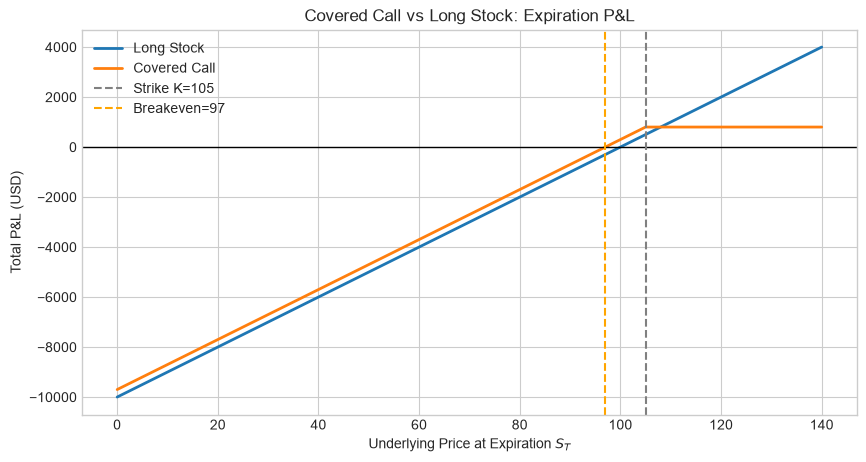

In [3]:
plt.figure(figsize=(10, 5))
plt.plot(expiry_prices, stock_pnl, label='Long Stock', linewidth=2)
plt.plot(expiry_prices, covered_call_pnl_values, label='Covered Call', linewidth=2)
plt.axhline(0, color='black', linewidth=1)
plt.axvline(strike, color='gray', linestyle='--', label=f'Strike K={strike}')
plt.axvline(breakeven, color='orange', linestyle='--', label=f'Breakeven={breakeven}')
plt.title('Covered Call vs Long Stock: Expiration P&L')
plt.xlabel('Underlying Price at Expiration $S_T$')
plt.ylabel('Total P&L (USD)')
plt.legend()
plt.show()

## 3. Risk Profile

- **Maximum profit**: `(strike - stock_cost + premium) × shares` = **$800**.
- **Maximum loss**: approximately `(stock_cost - premium) × shares` = **$9,700**, if the stock falls to zero.
- **Breakeven**: `stock_cost - premium` = **$97**.

The premium provides a small downside cushion, but it does not eliminate the main risk of owning the stock. The strategy is generally most attractive when you are neutral to moderately bullish and are willing to sell the shares at the strike.

In [4]:
sample_prices = [80, 97, 100, 105, 120]
sample = pd.DataFrame({
    'Underlying Price at Expiration': sample_prices,
    'Covered Call P&L': covered_call_pnl(sample_prices, stock_cost, strike, premium, shares)
})
sample

,Underlying Price at Expiration,Covered Call P&L
0,80,-1700
1,97,0
2,100,300
3,105,800
4,120,800


## 4. Exercises

1. Change `strike` to 110. How do maximum profit and the curve change?
2. Change `premium` to 5. What happens to breakeven and the downside cushion?
3. Calculate the P&L by hand when the stock expires at 90, 100, 105, and 120.
4. Why does the Covered Call stop gaining after the stock price rises above the strike?
5. In your own words, explain the tradeoff: income from premium versus capped upside.